<밑바닥부터 시작하는 딥러닝, 사이토 고키, 한빛미디어> => 현재 이 책 위주로 딥러닝 수업

https://karpathy.github.io/neuralnets/

https://cs231n.github.io/ => 강의 추천

위 두 링크는 '밑바닥부터 시작하는 딥러닝' 저자가 참고한 내용들

<기계학습, 오일석, 한빛아카데미> => 표현법이 다름 조금 시간 들여서 공부해야 함

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
from scipy.special import expit
import pickle
from drive.MyDrive.data.mnistdata.mnist import load_mnist

# 오차역전파

계산 그래프 : 계산과정을 그래프로 나타낸것
```
노드와 엣지로 표현
노드에는 연산자, 엣지에는 값을 사용
```

계산 그래프 사용
```
1. 계산그래프를 그린다.
2. 그래프에서 계산을 왼쪽에서 오른쪽으로 수행한다. (순전파)
```

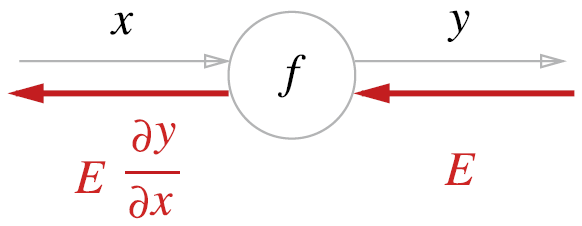

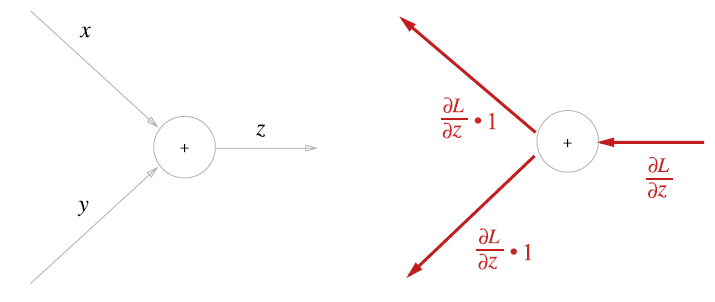

In [24]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

In [25]:
def sigmoid(x):
    return expit(x)

def sigmoid_grad(x):
    return (1.0 - sigmoid(x)) * sigmoid(x)

def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T
    x = x - np.max(x)
    return np.exp(x) / np.sum(np.exp(x))

def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
    if t.size == y.size:
        t = t.argmax(axis=1)
    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size

def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)
        x[idx] = tmp_val - h
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val
        it.iternext()
    return grad

In [26]:
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01): # 가중치를 weight_init_std 표준편차로 주겠다.
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        return y

    def loss(self, x, t):
        y = self.predict(x)
        return cross_entropy_error(y, t)

    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        return grads

    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}

        batch_num = x.shape[0]

        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        #backward
        dy = (y-t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)

        da1 = np.dot(dy, W2.T)
        dz1 = sigmoid_grad(a1) * da1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)
        return grads

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        accuracy_ = np.sum(y == t) / float(x.shape[0])
        return accuracy_

In [27]:
nwt_grads = TwoLayerNet(784, 50, 10)
x_batch = x_train[:4]
t_batch = t_train[:4]

In [28]:
grad_numerical = nwt_grads.numerical_gradient(x_batch, t_batch)
grad_back = nwt_grads.gradient(x_batch, t_batch)

In [30]:
for key in grad_numerical.keys():
    diff = np.average(np.abs(grad_back[key] - grad_numerical[key]))
    print(diff)

3.7659308609998513e-13
9.770459316821647e-13
1.504574649591195e-11
1.1946000577633952e-10


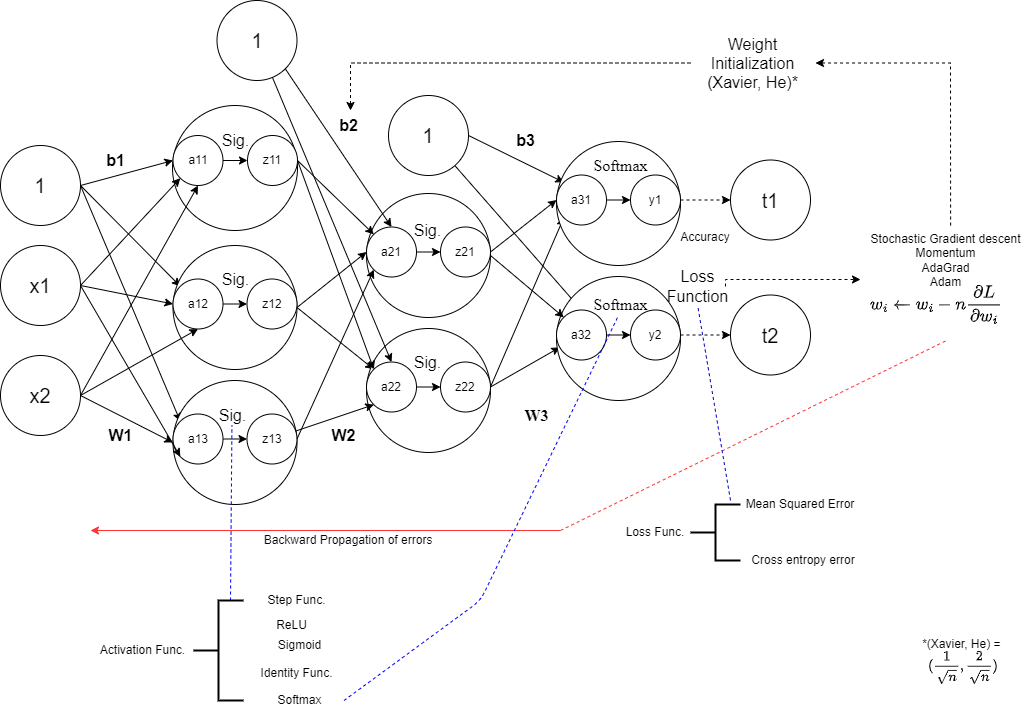

사과 3개 살 경우
```
100 * 3 * 1.1 = 330
3 * 110 = 330
```

사과 가격이 101로 올랐을 때
```
101 * 2.2 = 222.222...
```
이걸 식으로 나타냈을 때

$y = ax$<br>
a : 기울기

사과의 단가가 1 만큼 변했을 때  --> 총 가격은 2.2 만큼 변했다. --> $\partial  가격\over \partial 단가$ = 2.2 --> 기울기

매개변수 $w_i$가 1만큼 변했을 때 --> 손실함수 $L$은 2.2 만큼 변했다. --> $\partial L \over \partial w_i$ = 2.2 --> 기울기

# 곱셈에 대하여

$y = ax$ $\therefore \frac{\partial y}{\partial x}$

$$ z = x y
$$
\begin{equation*}
\frac{\partial z}{\partial x} = y
\end{equation*}
\begin{equation*}
\frac{\partial z}{\partial y} = x
\end{equation*}

# ReLU 역전파

\begin{equation*}
y = x ( x > 0 )
\end{equation*}
\begin{equation*}
y = 0 ( x <= 0 )
\end{equation*}
#### 위 식을 x에 대하여 각각 미분 하면
\begin{equation*}
\frac{\partial y}{\partial x} = 1 ( x > 0 )
\end{equation*}
\begin{equation*}
\frac{\partial y}{\partial x} = 0 ( x <= 0 )
\end{equation*}

In [34]:
class Relu:
    def __init__(self):
        self.mask = None

    # 순전파
    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout
        return dx

In [35]:
x = np.array([[1.0, 0.5], [-2.0, 3.0]])
x

array([[ 1. ,  0.5],
       [-2. ,  3. ]])

In [37]:
mask = (x <= 0)
mask

array([[False, False],
       [ True, False]])

In [40]:
out = x.copy()
out[mask] = 0
out

array([[1. , 0.5],
       [0. , 3. ]])

# Sigmoid

$$
\begin{equation*}
y = \frac{1}{1 + exp(-x)}
\end{equation*}
$$
<br>
<br>
\begin{equation*}
y = {1 \over x}\\
\frac{\partial y}{\partial x} = -\frac{1}{x^{2}}
\end{equation*}
\begin{equation*}
= - y^{2}
\end{equation*}

In [41]:
class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out
        return dx

Affine 변환<br>
: 신경망의 순전파에서 가중치 신호의 총 합을 계산하기 위해 수행하는 행렬곱

In [42]:
X = np.random.randn(2)
W = np.random.randn(2, 3)
B = np.random.randn(3)

In [43]:
X.shape, W.shape, B.shape

((2,), (2, 3), (3,))

$$
\frac{\partial L}{\partial W} = \frac{\partial L}{\partial Y} \frac{\partial Y}{\partial W}
$$

\begin{equation*}
\frac{\partial L}{\partial X}(N,2) = \frac{\partial L}{\partial Y}(N,3) W^{T} (3,2)
\end{equation*}
\begin{equation*}
\frac{\partial L}{\partial W}(2,3) = X^{T}(2,N) \frac{\partial L}{\partial Y} (N,3)
\end{equation*}
\begin{equation*}
\frac{\partial L}{\partial B}(3) = \frac{\partial L}{\partial Y} (N,3)의 첫번째 축 (axis = 0)의 합
\end{equation*}

In [45]:
class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b
        self.x = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        out = np.dot(x, self.W) + self.b
        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)
        return dx